In [ ]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [ ]:
class BatsmanStatus(TypedDict):
  runs:int
  balls:int
  four:int
  six:int

  sr:float
  ball_per_boundary:float
  boundary_percentage:float
  summery:str


In [ ]:
def calculate_sr(state:BatsmanStatus):
  sr=(state['runs']/state['balls'])*100
  return {'sr':sr}


In [ ]:
def calculate_ball_per_boundary(state:BatsmanStatus):
  ball_per_boundary=state['balls']/(state['four']+state['six'])
  return {'ball_per_boundary':ball_per_boundary}


In [ ]:
def calculate_boundary_percentage(state:BatsmanStatus):
  boundary_percentage=(state['four']+state['six'])/state['balls']*100
  return {'boundary_percentage':boundary_percentage}

In [ ]:
def summery(state:BatsmanStatus):
  summery=f"""
  Accoding to the given data the bats man status is:
          Strike Rate - {state['sr']} \n
          Balls per boundary - {state['ball_per_boundary']} \n
          Boundary percent - {state['boundary_percentage']}
  """
  return {'summery':summery}

In [ ]:
graph=StateGraph(BatsmanStatus)
#noads
graph.add_node("calculate_sr",calculate_sr)
graph.add_node("calculate_ball_per_boundary",calculate_ball_per_boundary)
graph.add_node("calculate_boundary_percentage",calculate_boundary_percentage)
graph.add_node("summery",summery)
#edges
graph.add_edge(START,"calculate_sr")
graph.add_edge(START,"calculate_ball_per_boundary")
graph.add_edge(START,"calculate_boundary_percentage")

graph.add_edge("calculate_sr","summery")
graph.add_edge("calculate_ball_per_boundary","summery")
graph.add_edge("calculate_boundary_percentage","summery")

graph.add_edge("summery",END)
workflow=graph.compile()

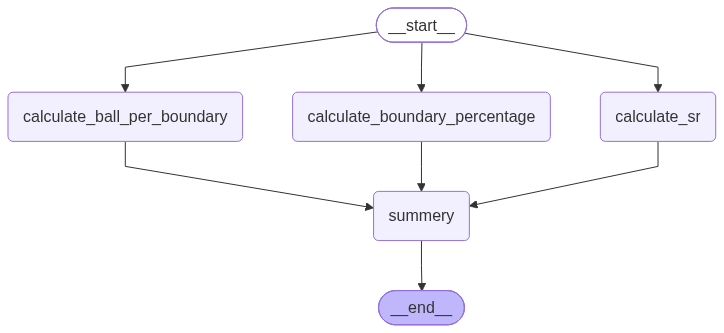

In [ ]:
workflow

In [ ]:
runs=int(input("Enter the runs:"))
balls=int(input("Enter the balls:"))
four=int(input("Enter the four:"))
six=int(input("Enter the six:"))
initial_state={
    'runs':runs,
    'balls':balls,
    'four':four,
    'six':six
}
print(initial_state)
#

Enter the runs:278
Enter the balls:167
Enter the four:45
Enter the six:34
{'runs': 278, 'balls': 167, 'four': 45, 'six': 34}


In [ ]:
output=workflow.invoke(initial_state)
# print(output.keys())  # Check what keys are available
print(output.get('summery'))

dict_keys(['runs', 'balls', 'four', 'six', 'sr', 'ball_per_boundary', 'boundary_percentage', 'summery'])

  Accoding to the given data the bats man status is:
          Strike Rate - 166.4670658682635 

          Balls per boundary - 2.1139240506329116 

          Boundary percent - 47.30538922155689
  
